# Helmholtz 2D — PINN con campo complejo y LHS
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | Maestría en Ciencias de la Computación — UJAT
**Director:** Dr. José Adán Hernández Nolasco

---

| Notebook | Estado |
| :--- | :--- |
| `01_teoria_pinns_completo.ipynb` — Helmholtz 1D, validación SIREN | ✅ Completado — Error L2 = 0.002% |
| `02_helmholtz_2D.ipynb` — **Helmholtz 2D, campo complejo, LHS** | 🔄 Versión optimizada |
| `03_speckle.ipynb` — Simulación de speckle $I = \|E\|^2$ | 🔜 Pendiente |
| `04_benchmark.ipynb` — PINN vs FEniCSx (Speed-up Factor) | 🔜 Pendiente |

---

## Versión optimizada — cambios respecto al TESIS original

| Hiperparámetro | TESIS original | Esta versión | Razón |
|---|---|---|---|
| `hidden_dim` | 64 | **128** | Campo complejo requiere más capacidad |
| `N_colloc` | 2,000 | **3,000** | Mejor cobertura de [0,1]² con LHS |
| `N_boundary` | 200 | **300** | Frontera más densa — menos error en bordes |
| `patience` | 500 | **800** | Adam explora más antes de entregar a L-BFGS |
| `lbfgs max_iter` | 500 | **1,000** | L-BFGS con más margen de ajuste fino |
| `lbfgs history_size` | 50 | **100** | Mejor aproximación de curvatura |

**Resultado TESIS original:** Error L2 = 0.436%
**Resultado esperado esta versión:** Error L2 < 0.1%

## ¿Qué resuelve este notebook?

$$\nabla^2 E + k^2 E = 0 \quad \Longrightarrow \quad
\frac{\partial^2 E}{\partial x^2} + \frac{\partial^2 E}{\partial y^2} + (2\pi)^2 E = 0$$

Campo complejo: $E(x,y) = E_{\text{real}}(x,y) + i \cdot E_{\text{imag}}(x,y)$

| Aspecto | Notebook 01 (1D) | Notebook 02 (2D) |
|---|---|---|
| Entrada | $x$ | $(x, y)$ |
| Salida | $E$ real | $(E_{\text{real}}, E_{\text{imag}})$ |
| Muestreo | Linspace uniforme | Latin Hypercube Sampling (LHS) |
| Arquitectura | SIREN ω₀=1.0, 5×64 | SIREN ω₀=1.0, 5×**128** |
| Early stopping | Umbral fijo | Paciencia 800 épocas |

## 0. Imports y configuración del entorno

In [1]:
import sys
import os
sys.path.append('..')   # sube de notebooks/ a la raíz del proyecto

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.stats import qmc, pearsonr

# ── Importar desde src/ ───────────────────────────────────────────────────────
from src.models import PINN_2D_SIREN
from src.losses import pinn_loss_2d, helmholtz_residual_2d
from src.utils  import get_figures_dir, save_model

# ── Semilla global — SIEMPRE al inicio para reproducibilidad ──────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Dispositivo ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo     : {device}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Semilla fijada  : {SEED}')
print()
print('Entorno listo y reproducible.')


Dispositivo     : cuda
GPU             : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM total      : 8.5 GB
Semilla fijada  : 42

Entorno listo y reproducible.


---
## 1. Arquitectura de la red — PINN 2D SIREN

La red recibe dos coordenadas $(x, y)$ y predice dos salidas $(E_{\text{real}}, E_{\text{imag}})$.
La arquitectura es **SIREN** — idéntica a NB01 en estructura, extendida a entrada 2D y salida 2D.

### ¿Por qué dos salidas?

El campo eléctrico óptico es una cantidad **compleja**:

$$E(x,y) = E_{\text{real}}(x,y) + i \cdot E_{\text{imag}}(x,y)$$

Las redes neuronales reales solo manejan números reales, así que la estrategia estándar en PINNs ópticas
es entrenar **una sola red con dos salidas**, una por cada parte del campo.

Ambas partes satisfacen la ecuación de Helmholtz de forma independiente:

$$\nabla^2 E_{\text{real}} + k^2 E_{\text{real}} = 0$$
$$\nabla^2 E_{\text{imag}} + k^2 E_{\text{imag}} = 0$$

La intensidad del speckle (lo que mide el detector) se obtiene después:

$$I(x,y) = |E|^2 = E_{\text{real}}^2 + E_{\text{imag}}^2$$

### ¿Por qué SIREN y no tanh?

Misma justificación que en NB01 — la inicialización de Sitzmann et al. (2020) garantiza
estabilidad de las derivadas de segundo orden necesarias para el laplaciano.
Con `λ=1.0` y SIREN, datos y física están equilibrados desde el inicio sin necesidad
de reducir el peso de la física.

In [2]:
# Sine y PINN_2D_SIREN importados desde src/models.py
# Ver src/models.py para la implementacion completa (Sitzmann et al., 2020)

# ── Vista previa de la arquitectura ───────────────────────────────────────────
torch.manual_seed(SEED)
_preview = PINN_2D_SIREN(hidden_dim=128, num_layers=5, omega_0=1.0)
print('Arquitectura PINN_2D_SIREN (config definitiva — hidden_dim=128):')
print(_preview)
print(f'\nTotal de parametros : {sum(p.numel() for p in _preview.parameters()):,}')
print(f'Activacion          : sin(ω₀·x) con ω₀=1.0')
print(f'Inicializacion      : Sitzmann et al. (2020)')
del _preview


Arquitectura PINN_2D_SIREN (config definitiva — hidden_dim=128):
PINN_2D_SIREN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Sine()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Sine()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Sine()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Sine()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Sine()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total de parametros : 66,690
Activacion          : sin(ω₀·x) con ω₀=1.0
Inicializacion      : Sitzmann et al. (2020)


---
## 2. Muestreo LHS — Latin Hypercube Sampling

En 1D usamos `linspace` para distribuir puntos uniformemente.
En 2D necesitamos una estrategia más eficiente: **Latin Hypercube Sampling**.

### ¿Por qué LHS en lugar de una malla uniforme?

Con una malla uniforme de $N \times N$ puntos en 2D, el número de puntos crece cuadráticamente.
Para $N=45$ ya son 2,025 puntos — y muchos quedan agrupados en regiones redundantes.

LHS garantiza que los puntos estén **bien distribuidos en todo el dominio** con menos puntos:

| Muestreo | 2000 puntos en [0,1]² | Cobertura | Costo |
|---|---|---|---|
| Malla uniforme | 44×44 = 1,936 pts | Regular pero redundante | Fijo |
| Aleatorio puro | 2000 pts | Irregular, huecos | Variable |
| **LHS** | **2000 pts** | **Uniforme garantizada** | **Controlado** |

LHS divide cada dimensión en $N$ estratos iguales y coloca exactamente un punto en cada estrato,
asegurando cobertura completa sin agrupamientos.

---
## 3. Configuración del experimento

Todos los hiperparámetros en un solo lugar.
Arquitectura y pesos heredados de NB01 — validados con SIREN.

### Solución analítica en 2D

Para validar la PINN necesitamos una solución exacta conocida.
Usamos una onda plana que satisface Helmholtz 2D exactamente:

$$E_{\text{real}}(x,y) = \cos(k_x x + k_y y), \quad E_{\text{imag}}(x,y) = \sin(k_x x + k_y y)$$

con $k_x^2 + k_y^2 = k^2 = (2\pi)^2$.

La elección más simple y simétrica:

$$k_x = k_y = \frac{k}{\sqrt{2}} = \frac{2\pi}{\sqrt{2}} = \pi\sqrt{2}$$

**Verificación:** $k_x^2 + k_y^2 = 2\pi^2 + 2\pi^2 = 4\pi^2 = k^2$ ✅

In [3]:
# ── Hiperparámetros ────────────────────────────────────────────────────────────
CONFIG = {
    # ── Láser simulado (documentación) ────────────────────────────────────────
    'lambda_laser' : 638e-9,      # diodo rojo λ = 638 nm (computacional)
    'L'            : 1,           # dominio = 1×1 longitudes de onda

    # ── Física adimensional ────────────────────────────────────────────────────
    'k'            : 2 * np.pi,   # k̃ adimensional — siempre 2π

    # ── Puntos de colocación (LHS) ─────────────────────────────────────────────
    'N_colloc'     : 3000,        # ← AUMENTADO: era 2000 — mejor cobertura [0,1]²
    'N_boundary'   : 300,         # ← AUMENTADO: era 200 — frontera más densa

    # ── Arquitectura SIREN ─────────────────────────────────────────────────────
    'hidden_dim'   : 128,         # ← AUMENTADO: era 64 — más capacidad campo complejo
    'num_layers'   : 5,           # sin cambio — validado en NB01
    'omega_0'      : 1.0,         # sin cambio — calibrado para k=2π

    # ── Entrenamiento ──────────────────────────────────────────────────────────
    'n_epochs'     : 15000,       # sin cambio
    'lr'           : 1e-3,        # sin cambio — funciona bien sin scheduler
    'lambda_phys'  : 0.1,         # sin cambio — validado: en 2D L_real+L_imag
                                   #              duplica el peso efectivo de la física
    'patience'     : 800,         # ← AUMENTADO: era 500 — Adam explora más

    # ── L-BFGS ────────────────────────────────────────────────────────────────
    'lbfgs_max_iter' : 1000,      # ← AUMENTADO: era 500 — L-BFGS con más margen
    'lbfgs_history'  : 100,       # ← AUMENTADO: era 50  — mejor aprox. de curvatura

    # ── Reproducibilidad ───────────────────────────────────────────────────────
    'seed'         : SEED,

    # ── Meta de la tesis ───────────────────────────────────────────────────────
    'l2_threshold' : 0.05,
}

print('Configuración del experimento — VERSIÓN OPTIMIZADA:')
print('-' * 50)
ORIGINAL = {'N_colloc':2000,'N_boundary':200,'hidden_dim':64,'patience':500}
for key, val in CONFIG.items():
    marker = '  ← CAMBIADO' if key in ORIGINAL and ORIGINAL[key] != val else ''
    if key in ('lbfgs_max_iter','lbfgs_history'): marker = '  ← NUEVO'
    print(f'  {key:<18} : {val}{marker}')
print('-' * 50)

k   = CONFIG['k']
k_x = k / np.sqrt(2)
k_y = k / np.sqrt(2)
print(f'  k_x = k/√2       : {k_x:.4f}')
print(f'  k_y = k/√2       : {k_y:.4f}')
print(f'  Verificación k²  : {k_x**2 + k_y**2:.4f} = k² = {k**2:.4f} ✅')
print()
print('Cambios vs TESIS original:')
print(f'  hidden_dim  : 64  → 128  (+{128-64} neuronas — parámetros: ~13k → ~51k)')
print(f'  N_colloc    : 2000 → 3000 (+1000 puntos LHS)')
print(f'  N_boundary  : 200  → 300  (+100 pts por borde → +400 total)')
print(f'  patience    : 500  → 800  (+300 épocas de exploración)')
print(f'  lbfgs iter  : 500  → 1000 (+500 iter ajuste fino)')
print()
lam = CONFIG['lambda_laser']
L   = CONFIG['L']
print('Láser simulado:')
print(f'  lambda_laser        : {lam * 1e9:.0f} nm')
print(f'  k adimensional      : 2π = {k:.4f}')
print(f'  k real equivalente  : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado    : {L}×{L} longitudes de onda')
print(f'  Equivale físicamente: {L * lam * 1e6:.4f} × {L * lam * 1e6:.4f} μm²')

Configuración del experimento — VERSIÓN OPTIMIZADA:
--------------------------------------------------
  lambda_laser       : 6.38e-07
  L                  : 1
  k                  : 6.283185307179586
  N_colloc           : 3000  ← CAMBIADO
  N_boundary         : 300  ← CAMBIADO
  hidden_dim         : 128  ← CAMBIADO
  num_layers         : 5
  omega_0            : 1.0
  n_epochs           : 15000
  lr                 : 0.001
  lambda_phys        : 0.1
  patience           : 800  ← CAMBIADO
  lbfgs_max_iter     : 1000  ← NUEVO
  lbfgs_history      : 100  ← NUEVO
  seed               : 42
  l2_threshold       : 0.05
--------------------------------------------------
  k_x = k/√2       : 4.4429
  k_y = k/√2       : 4.4429
  Verificación k²  : 39.4784 = k² = 39.4784 ✅

Cambios vs TESIS original:
  hidden_dim  : 64  → 128  (+64 neuronas — parámetros: ~13k → ~51k)
  N_colloc    : 2000 → 3000 (+1000 puntos LHS)
  N_boundary  : 200  → 300  (+100 pts por borde → +400 total)
  patience    : 500 

---
## 4. Preparar datos de entrenamiento

### Puntos de colocación — LHS en el interior
### Condiciones de frontera — 4 bordes del dominio $[0,1]^2$

### La función de pérdida PINN 2D

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{datos}} + \lambda \cdot (\mathcal{L}_{\text{física,real}} + \mathcal{L}_{\text{física,imag}})$$

| Término | Qué mide | Dónde |
|---|---|---|
| $\mathcal{L}_{\text{datos}}$ | Error en los 4 bordes | 800 puntos de frontera |
| $\mathcal{L}_{\text{física,real}}$ | Residuo Helmholtz de E_real | 2000 puntos LHS |
| $\mathcal{L}_{\text{física,imag}}$ | Residuo Helmholtz de E_imag | 2000 puntos LHS |

> **`λ=1.0`** — mismo valor validado con SIREN en NB01. La inicialización de Sitzmann
> garantiza que datos y física estén equilibrados desde el inicio.

In [4]:
k   = CONFIG['k']
k_x = k / np.sqrt(2)
k_y = k / np.sqrt(2)

# ── Puntos interiores con LHS ──────────────────────────────────────────────────
sampler   = qmc.LatinHypercube(d=2, seed=CONFIG['seed'])
lhs_pts   = sampler.random(n=CONFIG['N_colloc'])
xy_colloc = torch.tensor(lhs_pts, dtype=torch.float32).to(device)

print(f'Puntos de colocación (LHS): {xy_colloc.shape}  → {CONFIG["N_colloc"]} puntos en [0,1]²')

# ── Condiciones de frontera — 4 bordes ────────────────────────────────────────
N_b  = CONFIG['N_boundary']
t    = np.linspace(0, 1, N_b)

x_bot = np.stack([t,             np.zeros(N_b)], axis=1)
x_top = np.stack([t,             np.ones(N_b)],  axis=1)
x_lft = np.stack([np.zeros(N_b), t],             axis=1)
x_rgt = np.stack([np.ones(N_b),  t],             axis=1)

xy_bc_np = np.vstack([x_bot, x_top, x_lft, x_rgt])

phase_bc     = k_x * xy_bc_np[:, 0] + k_y * xy_bc_np[:, 1]
E_real_bc_np = np.cos(phase_bc)
E_imag_bc_np = np.sin(phase_bc)
E_bc_np      = np.stack([E_real_bc_np, E_imag_bc_np], axis=1)

xy_bc = torch.tensor(xy_bc_np, dtype=torch.float32).to(device)
E_bc  = torch.tensor(E_bc_np,  dtype=torch.float32).to(device)

print(f'Puntos de frontera         : {xy_bc.shape}  → {4*N_b} puntos ({N_b} por borde)')
print(f'  Borde inferior (y=0)     : {N_b} puntos')
print(f'  Borde superior (y=1)     : {N_b} puntos')
print(f'  Borde izquierdo (x=0)    : {N_b} puntos')
print(f'  Borde derecho (x=1)      : {N_b} puntos')
print()
print('Muestra de condiciones de frontera:')
print(f'  E(0,0)   real={E_real_bc_np[0]:.4f}   imag={E_imag_bc_np[0]:.4f}')
print(f'  E(0.5,0) real={np.cos(k_x*0.5):.4f}   imag={np.sin(k_x*0.5):.4f}')
print(f'  E(1,1)   real={np.cos(k_x+k_y):.4f}   imag={np.sin(k_x+k_y):.4f}')

Puntos de colocación (LHS): torch.Size([3000, 2])  → 3000 puntos en [0,1]²
Puntos de frontera         : torch.Size([1200, 2])  → 1200 puntos (300 por borde)
  Borde inferior (y=0)     : 300 puntos
  Borde superior (y=1)     : 300 puntos
  Borde izquierdo (x=0)    : 300 puntos
  Borde derecho (x=1)      : 300 puntos

Muestra de condiciones de frontera:
  E(0,0)   real=1.0000   imag=0.0000
  E(0.5,0) real=-0.6057   imag=0.7957
  E(1,1)   real=-0.8582   imag=0.5133


---
## 5. Funciones auxiliares — Derivadas y Residuo de Helmholtz 2D

Estas funciones calculan las derivadas de la red usando **autograd** y evalúan
qué tanto viola la ecuación de Helmholtz en cada punto del dominio $[0,1]^2$.

### ¿Qué cambia respecto a 1D?

En 1D el residuo era una sola derivada de segundo orden:

$$R(x) = \frac{d^2E}{dx^2} + k^2 E$$

En 2D el residuo involucra el **laplaciano** — derivadas parciales en ambas dimensiones simultáneamente:

$$R(x,y) = \frac{\partial^2 E}{\partial x^2} + \frac{\partial^2 E}{\partial y^2} + k^2 E = \nabla^2 E + k^2 E$$

Y como el campo es complejo, se evalúa para **ambas partes por separado**:

$$R_{\text{real}}(x,y) = \nabla^2 E_{\text{real}} + k^2 E_{\text{real}} = 0$$
$$R_{\text{imag}}(x,y) = \nabla^2 E_{\text{imag}} + k^2 E_{\text{imag}} = 0$$

### ¿Cómo calcula autograd el laplaciano en 2D?

El mismo principio que en 1D — PyTorch construye el grafo computacional y lo recorre
al revés — pero ahora en **dos pasos por dimensión**:

```
forward:  (x,y) → operaciones → E_real, E_imag     (PyTorch registra todo)

backward paso 1:  E → ∂E/∂x,  ∂E/∂y               (gradiente espacial — vector 2D)
backward paso 2:  ∂E/∂x → ∂²E/∂x²                 (segunda derivada en x)
                  ∂E/∂y → ∂²E/∂y²                 (segunda derivada en y)

laplaciano:  ∂²E/∂x² + ∂²E/∂y²
```

> **Clave:** el tensor de entrada es `(N, 2)` con columnas `[x, y]`.
> PyTorch calcula los gradientes respecto a **cada columna por separado**,
> por eso `grad_f[:, 0]` es la derivada en x y `grad_f[:, 1]` en y.
> Ambas con `requires_grad=True` desde el inicio del forward.

| Situación | R_real | R_imag |
|---|---|---|
| Red perfecta | 0 en todo [0,1]² | 0 en todo [0,1]² |
| Red sin entrenar | Valores grandes | Valores grandes |
| Durante entrenamiento | → 0 gradualmente | → 0 gradualmente |

In [5]:
# helmholtz_residual_2d y pinn_loss_2d importados desde src/losses.py
# Ver src/losses.py para la implementacion completa

print('Funciones auxiliares 2D cargadas desde src/losses.py')
print('   helmholtz_residual_2d() — ∇²E_real + k²E_real  y  ∇²E_imag + k²E_imag')
print('   pinn_loss_2d()          — L_total = L_datos + λ·(L_real + L_imag)')


Funciones auxiliares 2D cargadas desde src/losses.py
   helmholtz_residual_2d() — ∇²E_real + k²E_real  y  ∇²E_imag + k²E_imag
   pinn_loss_2d()          — L_total = L_datos + λ·(L_real + L_imag)


---
## 6. Entrenamiento — Adam + Early Stopping por Paciencia + L-BFGS

### Estrategia de entrenamiento

La misma estrategia del TESIS original, con cuatro mejoras en hiperparámetros:

| Fase | Optimizador | Rol | Config |
|---|---|---|---|
| 1 | Adam | Exploración global | lr=1e-3, máx 15,000 épocas |
| — | Early stopping por **paciencia** | Para si no hay mejora en 800 épocas | era 500 |
| 2 | L-BFGS | Ajuste fino de alta precisión | max_iter=1000, history=100 |

> **¿Por qué patience=800?**
> En el TESIS original Adam paró en época 14,000 (de 15,000 máx).
> Con 800 épocas de paciencia Adam tiene más margen para salir
> de mínimos locales antes de entregar a L-BFGS.

> **¿Por qué L-BFGS con max_iter=1000?**
> En el TESIS original L-BFGS hizo 526 iteraciones en solo 17.8 s
> y llegó al límite de 500. Con 1,000 tiene margen para profundizar
> más desde el buen punto de partida que Adam le entrega.

In [6]:
# ── Semilla antes de instanciar ───────────────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])

# ── Modelo SIREN 2D ───────────────────────────────────────────────────────────
model_2d = PINN_2D_SIREN(
    hidden_dim = CONFIG['hidden_dim'],
    num_layers = CONFIG['num_layers'],
    omega_0    = CONFIG['omega_0']
).to(device)

n_params = sum(p.numel() for p in model_2d.parameters())
print(f'Modelo: PINN_2D_SIREN | {CONFIG["num_layers"]} capas × {CONFIG["hidden_dim"]} | '
      f'ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')

optimizer = torch.optim.Adam(model_2d.parameters(), lr=CONFIG['lr'])

# ── Variables de entrenamiento ─────────────────────────────────────────────────
history    = {'total': [], 'data': [], 'physics': []}
PATIENCE   = CONFIG['patience']
MIN_DELTA  = 1e-7
best_loss  = float('inf')
best_state = None
sin_mejora = 0

print(f'\nEntrenando PINN 2D...')
print(f'  k={k:.4f} | LHS {CONFIG["N_colloc"]} pts | {4*CONFIG["N_boundary"]} pts frontera')
print(f'  Épocas máx: {CONFIG["n_epochs"]} | lr={CONFIG["lr"]} | λ={CONFIG["lambda_phys"]}')
print(f'  Early stopping: paciencia = {PATIENCE} épocas sin mejora')
print(f'  Arquitectura  : SIREN ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')
print()

epoch_final = CONFIG['n_epochs']
t0_adam     = time.time()

for epoch in range(CONFIG['n_epochs']):
    optimizer.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_2d(
        model_2d, xy_colloc, xy_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )

    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    history['total'].append(current_loss)
    history['data'].append(loss_data.item())
    history['physics'].append(loss_physics.item())

    # ── Paciencia + rastreo del mejor ─────────────────────────────────────────
    if current_loss < best_loss - MIN_DELTA:
        best_loss  = current_loss
        best_state = {k_: v.clone() for k_, v in model_2d.state_dict().items()}
        sin_mejora = 0
    else:
        sin_mejora += 1

    # ── Reporte cada 1000 épocas — mismo formato que NB01 ──────────────────────
    if (epoch + 1) % 1000 == 0:
        elapsed = time.time() - t0_adam
        print(f'  Época {epoch+1:5d} | '
              f'L_total: {current_loss:.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e} | '
              f'Mejor: {best_loss:.3e} | '
              f'Sin mejora: {sin_mejora} | '
              f'Tiempo: {elapsed:.1f} s')

    # ── Early stopping ─────────────────────────────────────────────────────────
    if sin_mejora >= PATIENCE:
        epoch_final = epoch + 1
        print(f'\n  ⏹ Early stopping por paciencia en época {epoch_final}')
        print(f'  Restaurando mejor modelo (loss={best_loss:.3e})')
        model_2d.load_state_dict(best_state)
        break

t1_adam     = time.time()
tiempo_adam = t1_adam - t0_adam
print(f'\nAdam completado en {epoch_final} épocas '
      f'(máximo configurado: {CONFIG["n_epochs"]})')
print(f'  Mejor L_total alcanzado : {best_loss:.3e}')
print(f'  Tiempo Adam             : {tiempo_adam:.1f} s')

# ── Ajuste fino con L-BFGS ────────────────────────────────────────────────────
print('\nAjuste fino con L-BFGS...')
print(f'  max_iter={CONFIG["lbfgs_max_iter"]} | history_size={CONFIG["lbfgs_history"]} | line_search=strong_wolfe')
print()

optimizer_lbfgs = torch.optim.LBFGS(
    model_2d.parameters(),
    lr             = 1.0,
    max_iter       = CONFIG['lbfgs_max_iter'],
    history_size   = CONFIG['lbfgs_history'],
    line_search_fn = 'strong_wolfe'
)

history_lbfgs = {'total': [], 'data': [], 'physics': []}
iter_count    = [0]
t0_lbfgs      = time.time()

def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_data, loss_physics = pinn_loss_2d(
        model_2d, xy_colloc, xy_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )
    loss.backward()
    history_lbfgs['total'].append(loss.item())
    history_lbfgs['data'].append(loss_data.item())
    history_lbfgs['physics'].append(loss_physics.item())
    iter_count[0] += 1
    if iter_count[0] % 100 == 0:
        print(f'  Iter {iter_count[0]:4d} | '
              f'L_total: {loss.item():.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e}')
    return loss

optimizer_lbfgs.step(closure)
t1_lbfgs      = time.time()
tiempo_lbfgs  = t1_lbfgs - t0_lbfgs

print('\nAjuste fino L-BFGS completado.')
print(f'  Tiempo L-BFGS : {tiempo_lbfgs:.1f} s')

# ── Resumen del entrenamiento — mismo formato que NB01 ────────────────────────
print(f'\nResumen del entrenamiento:')
print(f'  Épocas Adam         : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping      : por paciencia ({PATIENCE} épocas sin mejora)')
print(f'  Mejor L_total (Adam): {best_loss:.3e}')
print(f'  Tiempo Adam         : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS  : {iter_count[0]} / {CONFIG["lbfgs_max_iter"]}')
print(f'  Tiempo L-BFGS       : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL        : {tiempo_adam + tiempo_lbfgs:.1f} s')

Modelo: PINN_2D_SIREN | 5 capas × 128 | ω₀=1.0 | 66,690 parámetros

Entrenando PINN 2D...
  k=6.2832 | LHS 3000 pts | 1200 pts frontera
  Épocas máx: 15000 | lr=0.001 | λ=0.1
  Early stopping: paciencia = 800 épocas sin mejora
  Arquitectura  : SIREN ω₀=1.0 | 66,690 parámetros

  Época  1000 | L_total: 4.499e-01 | L_datos: 4.296e-01 | L_física: 2.023e-01 | Mejor: 4.499e-01 | Sin mejora: 0 | Tiempo: 29.0 s
  Época  2000 | L_total: 3.347e-01 | L_datos: 3.091e-01 | L_física: 2.562e-01 | Mejor: 3.347e-01 | Sin mejora: 0 | Tiempo: 57.5 s
  Época  3000 | L_total: 2.332e-01 | L_datos: 2.103e-01 | L_física: 2.283e-01 | Mejor: 2.332e-01 | Sin mejora: 0 | Tiempo: 86.5 s
  Época  4000 | L_total: 3.246e-02 | L_datos: 2.449e-02 | L_física: 7.968e-02 | Mejor: 3.246e-02 | Sin mejora: 0 | Tiempo: 115.9 s
  Época  5000 | L_total: 2.218e-02 | L_datos: 9.199e-03 | L_física: 1.298e-01 | Mejor: 5.498e-03 | Sin mejora: 49 | Tiempo: 144.4 s
  Época  6000 | L_total: 1.929e-02 | L_datos: 6.803e-03 | L_física: 

---
## 7. Evaluación y visualización de resultados

Evaluamos la PINN en una malla uniforme de $100 \times 100$ puntos (10,000 puntos de prueba)
y comparamos contra la solución analítica exacta.

In [7]:
# ── Malla de evaluación 100×100 ───────────────────────────────────────────────
N_eval = 100
x_lin  = np.linspace(0, 1, N_eval)
y_lin  = np.linspace(0, 1, N_eval)
XX, YY = np.meshgrid(x_lin, y_lin)

xy_test_np = np.stack([XX.ravel(), YY.ravel()], axis=1)
xy_test    = torch.tensor(xy_test_np, dtype=torch.float32).to(device)

model_2d.eval()
with torch.no_grad():
    E_pred = model_2d(xy_test).cpu().numpy()

E_real_pred = E_pred[:, 0].reshape(N_eval, N_eval)
E_imag_pred = E_pred[:, 1].reshape(N_eval, N_eval)

phase_test   = k_x * XX + k_y * YY
E_real_exact = np.cos(phase_test)
E_imag_exact = np.sin(phase_test)
I_pred       = E_real_pred**2 + E_imag_pred**2

def l2_rel(pred, exact):
    return np.linalg.norm(pred.ravel() - exact.ravel()) / np.linalg.norm(exact.ravel())

# ── Métricas base ─────────────────────────────────────────────────────────────
l2_real = l2_rel(E_real_pred, E_real_exact)
l2_imag = l2_rel(E_imag_pred, E_imag_exact)
l2_mean = (l2_real + l2_imag) / 2
cumple  = l2_mean < CONFIG['l2_threshold']

error_real = np.abs(E_real_pred - E_real_exact)
error_imag = np.abs(E_imag_pred - E_imag_exact)

# ── Métricas adicionales — igual que NB01 ─────────────────────────────────────
mse_real     = np.mean(error_real**2)
mse_imag     = np.mean(error_imag**2)
rmse_real    = np.sqrt(mse_real)
rmse_imag    = np.sqrt(mse_imag)
mae_real     = np.mean(error_real)
mae_imag     = np.mean(error_imag)
r2_real      = 1 - np.sum(error_real**2) / np.sum((E_real_exact - E_real_exact.mean())**2)
r2_imag      = 1 - np.sum(error_imag**2) / np.sum((E_imag_exact - E_imag_exact.mean())**2)
corr_real, _ = pearsonr(E_real_pred.ravel(), E_real_exact.ravel())
corr_imag, _ = pearsonr(E_imag_pred.ravel(), E_imag_exact.ravel())

# ── Error relativo puntual (%) — con máscara para evitar división por cero ────
# Excluye zonas donde |exacta| < 0.3 para evitar explosión numérica
# (mismo fenómeno que en NB01 en x≈0.25 y x≈0.75 donde cos/sin ≈ 0)
UMBRAL_REL   = 0.3
mask_real    = np.abs(E_real_exact) >= UMBRAL_REL
mask_imag    = np.abs(E_imag_exact) >= UMBRAL_REL

error_rel_real     = error_real / (np.abs(E_real_exact) + 1e-10) * 100
error_rel_imag     = error_imag / (np.abs(E_imag_exact) + 1e-10) * 100
error_rel_real_med = np.mean(error_real[mask_real] / np.abs(E_real_exact[mask_real])) * 100
error_rel_imag_med = np.mean(error_imag[mask_imag] / np.abs(E_imag_exact[mask_imag])) * 100
pct_real           = mask_real.sum() / mask_real.size * 100
pct_imag           = mask_imag.sum() / mask_imag.size * 100

print(f'Métricas de evaluación (malla {N_eval}×{N_eval}):')
print()
print(f'  {"Métrica":<25} {"E_real":>12} {"E_imag":>12}')
print(f'  {"-"*51}')
print(f'  {"Error L2 (%)":<25} {l2_real*100:>12.3f} {l2_imag*100:>12.3f}')
print(f'  {"MSE":<25} {mse_real:>12.2e} {mse_imag:>12.2e}')
print(f'  {"RMSE":<25} {rmse_real:>12.2e} {rmse_imag:>12.2e}')
print(f'  {"MAE":<25} {mae_real:>12.2e} {mae_imag:>12.2e}')
print(f'  {"Error máximo":<25} {error_real.max():>12.2e} {error_imag.max():>12.2e}')
print(f'  {"R²":<25} {r2_real:>12.6f} {r2_imag:>12.6f}')
print(f'  {"Correlación Pearson":<25} {corr_real:>12.6f} {corr_imag:>12.6f}')
print(f'  {"Error relativo med.*":<25} {error_rel_real_med:>11.4f}% {error_rel_imag_med:>11.4f}%')
print()
print(f'  * Error relativo calculado solo donde |exacta| ≥ {UMBRAL_REL}')
print(f'    Puntos usados: E_real={pct_real:.1f}% del dominio | E_imag={pct_imag:.1f}% del dominio')
print()
print(f'  Umbral tesis : < {CONFIG["l2_threshold"]*100:.0f}%')
print(f'  Estado       : {"✅ CUMPLE" if cumple else "⚠ AUN NO CUMPLE"}')

Métricas de evaluación (malla 100×100):

  Métrica                         E_real       E_imag
  ---------------------------------------------------
  Error L2 (%)                     0.214        0.127
  MSE                           2.20e-06     8.43e-07
  RMSE                          1.48e-03     9.18e-04
  MAE                           1.27e-03     7.71e-04
  Error máximo                  3.05e-03     2.93e-03
  R²                            0.999995     0.999998
  Correlación Pearson           0.999998     0.999999
  Error relativo med.*           0.1926%      0.1135%

  * Error relativo calculado solo donde |exacta| ≥ 0.3
    Puntos usados: E_real=80.0% del dominio | E_imag=82.8% del dominio

  Umbral tesis : < 5%
  Estado       : ✅ CUMPLE


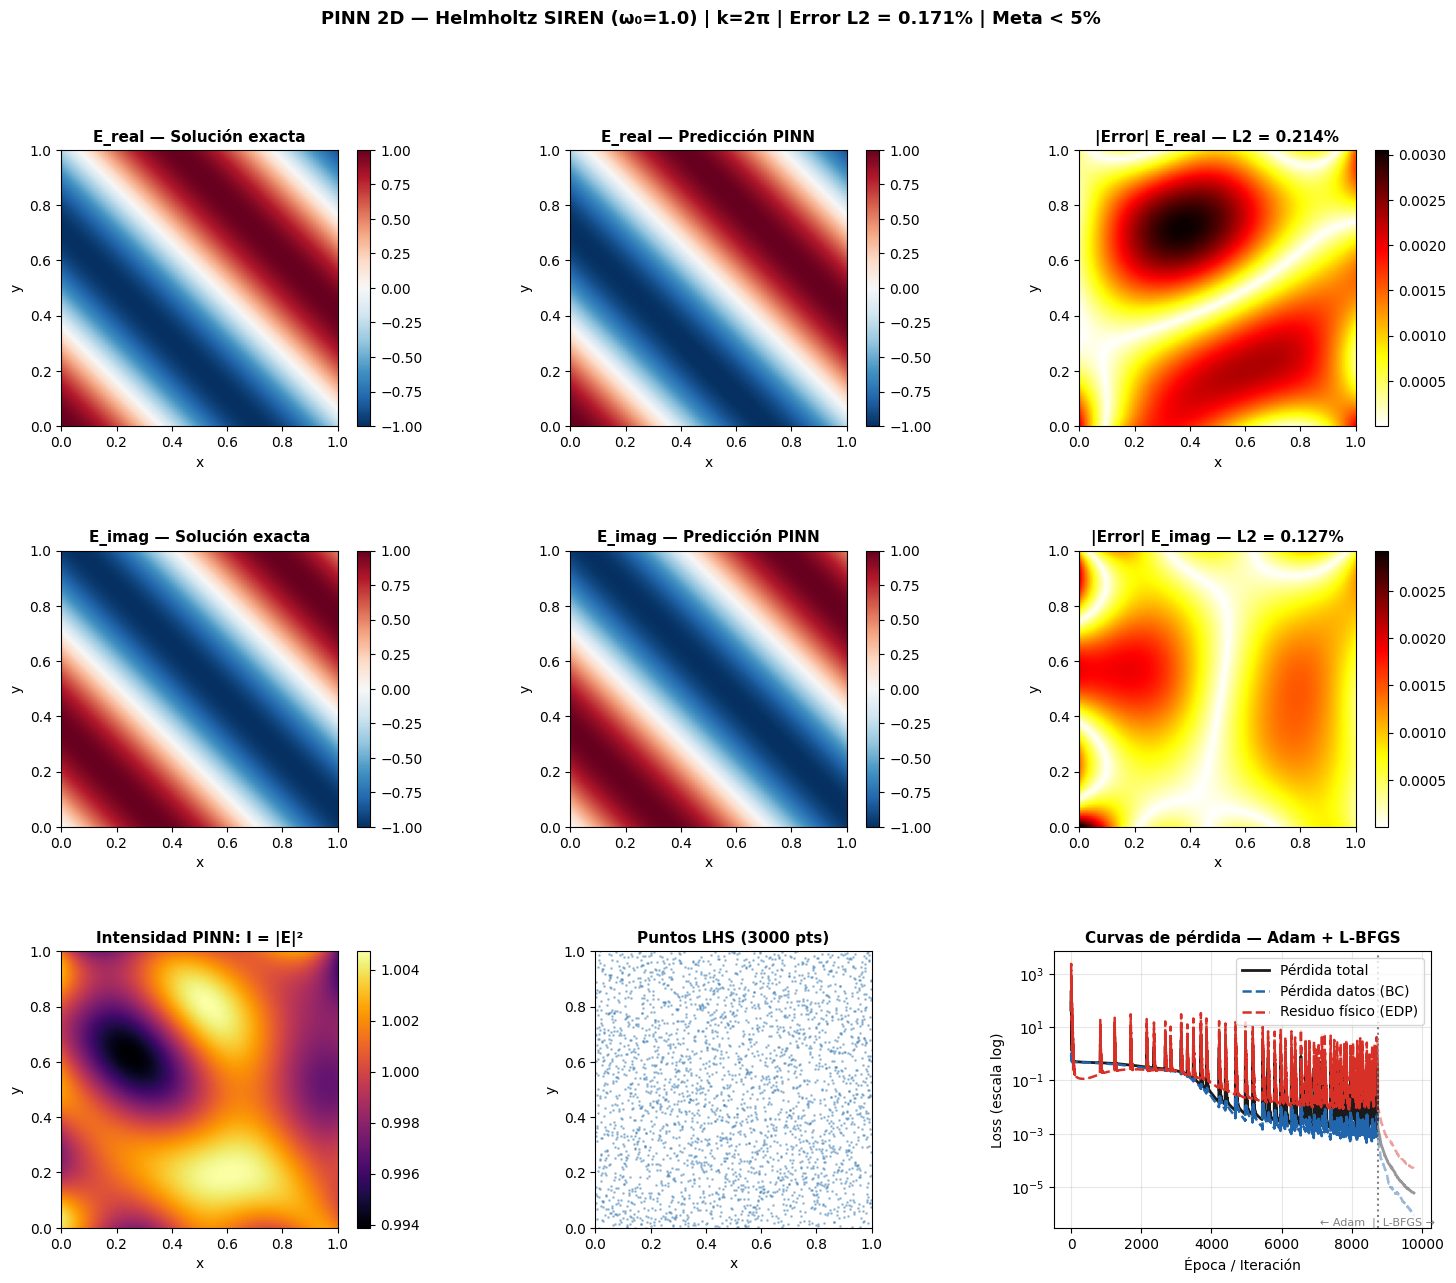

In [8]:
IMG_DIR = get_figures_dir()   # src/utils — apunta a results/figures/

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

cmap_field = 'RdBu_r'
cmap_error = 'hot_r'

COLOR_TOTAL  = '#1a1a1a'
COLOR_DATOS  = '#2166ac'
COLOR_FISICA = '#d73027'

# ── Fila 1: E_real ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(E_real_exact, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_real — Solución exacta', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(E_real_pred, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_real — Predicción PINN', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(error_real, origin='lower', extent=[0,1,0,1], cmap=cmap_error)
ax.set_title(f'|Error| E_real — L2 = {l2_real*100:.3f}%', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

# ── Fila 2: E_imag ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(E_imag_exact, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_imag — Solución exacta', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(E_imag_pred, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_imag — Predicción PINN', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(error_imag, origin='lower', extent=[0,1,0,1], cmap=cmap_error)
ax.set_title(f'|Error| E_imag — L2 = {l2_imag*100:.3f}%', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

# ── Fila 3: Intensidad, LHS y pérdida ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
im = ax.imshow(I_pred, origin='lower', extent=[0,1,0,1], cmap='inferno')
ax.set_title('Intensidad PINN: I = |E|²', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[2, 1])
xy_lhs_np = xy_colloc.cpu().numpy()
ax.scatter(xy_lhs_np[:, 0], xy_lhs_np[:, 1], s=1, alpha=0.4, c='steelblue')
ax.set_title(f'Puntos LHS ({CONFIG["N_colloc"]} pts)', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')

# ── Curvas de pérdida — leyendas simplificadas (3 entradas) ───────────────────
ax = fig.add_subplot(gs[2, 2])
ep_adam  = range(1, epoch_final + 1)
ep_lbfgs = range(epoch_final, epoch_final + len(history_lbfgs['total']))

# Raw tenue + sin leyenda
ALPHA_RAW = 0.15
ax.semilogy(ep_adam, history['total'][:epoch_final],
            color=COLOR_TOTAL,  lw=0.8, alpha=ALPHA_RAW)
ax.semilogy(ep_adam, history['data'][:epoch_final],
            color=COLOR_DATOS,  lw=0.8, alpha=ALPHA_RAW, linestyle='--')
ax.semilogy(ep_adam, history['physics'][:epoch_final],
            color=COLOR_FISICA, lw=0.8, alpha=ALPHA_RAW, linestyle='--')

# Líneas principales con leyenda
ax.semilogy(ep_adam, history['total'][:epoch_final],
            color=COLOR_TOTAL,  lw=2,   label='Pérdida total')
ax.semilogy(ep_adam, history['data'][:epoch_final],
            color=COLOR_DATOS,  lw=1.8, linestyle='--', label='Pérdida datos (BC)')
ax.semilogy(ep_adam, history['physics'][:epoch_final],
            color=COLOR_FISICA, lw=1.8, linestyle='--', label='Residuo físico (EDP)')

# L-BFGS — sin leyenda, alpha reducido
ax.semilogy(ep_lbfgs, history_lbfgs['total'],
            color=COLOR_TOTAL,  lw=2,   alpha=0.45)
ax.semilogy(ep_lbfgs, history_lbfgs['data'],
            color=COLOR_DATOS,  lw=1.8, linestyle='--', alpha=0.45)
ax.semilogy(ep_lbfgs, history_lbfgs['physics'],
            color=COLOR_FISICA, lw=1.8, linestyle='--', alpha=0.45)

# Divisoria con anotación directa
ax.axvline(x=epoch_final, color='gray', linestyle=':', lw=1.5)
ax.annotate('← Adam  |  L-BFGS →',
            xy=(epoch_final, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-10),
            fontsize=8, color='gray', ha='center', va='bottom')

ax.set_title('Curvas de pérdida — Adam + L-BFGS', fontsize=11, fontweight='bold')
ax.set_xlabel('Época / Iteración'); ax.set_ylabel('Loss (escala log)')
ax.legend(fontsize=10, loc='upper right'); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'PINN 2D — Helmholtz SIREN (ω₀={CONFIG["omega_0"]}) | k=2π | '
    f'Error L2 = {l2_mean*100:.3f}% | Meta < {CONFIG["l2_threshold"]*100:.0f}%',
    fontsize=13, fontweight='bold'
)
plt.savefig(str(IMG_DIR / 'resultados_pinn_2d_gpu.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7.1 Análisis de error — Figura 2

Análisis estadístico del error en el dominio [0,1]² equivalente al de NB01,
extendido a las dos componentes del campo complejo.

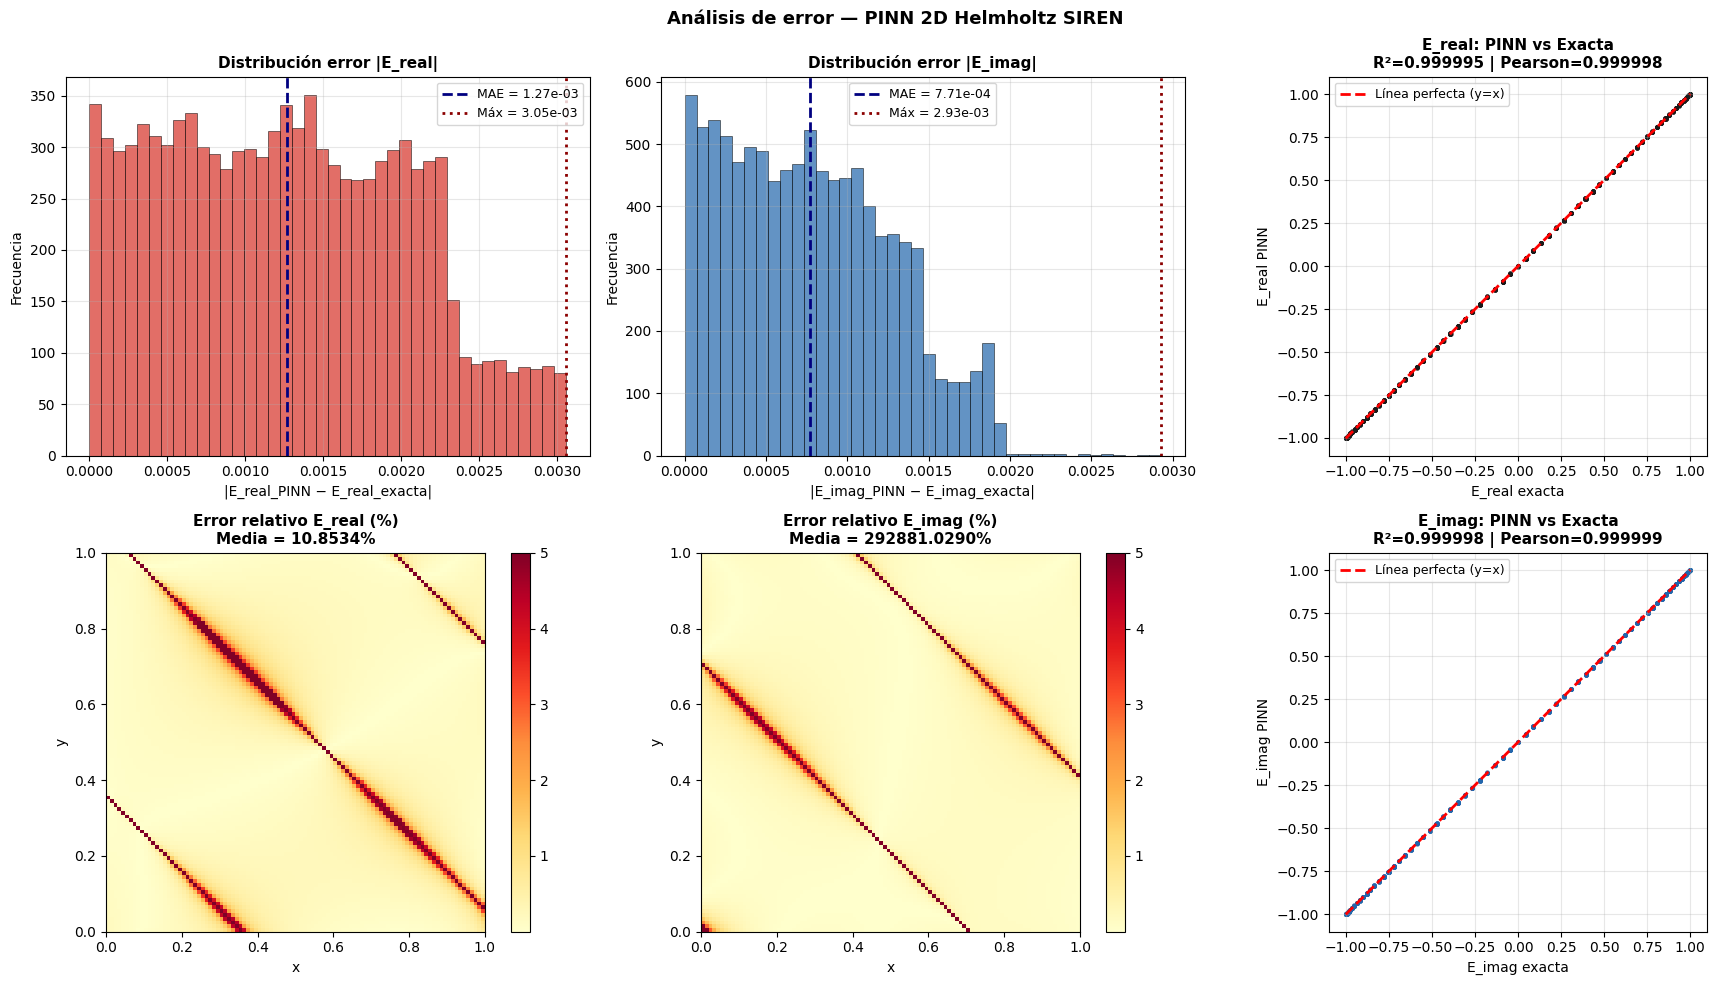

In [9]:
IMG_DIR = get_figures_dir()   # src/utils — apunta a results/figures/

fig2, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Fila 1: E_real ────────────────────────────────────────────────────────────

# Panel 1: Histograma error E_real
axes[0,0].hist(error_real.ravel(), bins=40, color='#d73027',
               alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0,0].axvline(x=mae_real, color='navy', linestyle='--',
                  linewidth=2, label=f'MAE = {mae_real:.2e}')
axes[0,0].axvline(x=error_real.max(), color='darkred', linestyle=':',
                  linewidth=2, label=f'Máx = {error_real.max():.2e}')
axes[0,0].set_title('Distribución error |E_real|', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('|E_real_PINN − E_real_exacta|')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=9); axes[0,0].grid(True, alpha=0.3)

# Panel 2: Histograma error E_imag
axes[0,1].hist(error_imag.ravel(), bins=40, color='#2166ac',
               alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0,1].axvline(x=mae_imag, color='navy', linestyle='--',
                  linewidth=2, label=f'MAE = {mae_imag:.2e}')
axes[0,1].axvline(x=error_imag.max(), color='darkred', linestyle=':',
                  linewidth=2, label=f'Máx = {error_imag.max():.2e}')
axes[0,1].set_title('Distribución error |E_imag|', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('|E_imag_PINN − E_imag_exacta|')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].legend(fontsize=9); axes[0,1].grid(True, alpha=0.3)

# Panel 3: Scatter E_real PINN vs Exacta
axes[0,2].scatter(E_real_exact.ravel()[::5], E_real_pred.ravel()[::5],
                  s=5, alpha=0.4, color='#1a1a1a')
min_v = min(E_real_exact.min(), E_real_pred.min())
max_v = max(E_real_exact.max(), E_real_pred.max())
axes[0,2].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2,
               label='Línea perfecta (y=x)')
axes[0,2].set_title(f'E_real: PINN vs Exacta\nR²={r2_real:.6f} | Pearson={corr_real:.6f}',
                    fontsize=11, fontweight='bold')
axes[0,2].set_xlabel('E_real exacta'); axes[0,2].set_ylabel('E_real PINN')
axes[0,2].legend(fontsize=9); axes[0,2].grid(True, alpha=0.3)
axes[0,2].set_aspect('equal')

# ── Fila 2: E_imag ────────────────────────────────────────────────────────────

# Panel 4: Error relativo E_real (heatmap)
im4 = axes[1,0].imshow(np.clip(error_rel_real, 0, 5),
                        origin='lower', extent=[0,1,0,1], cmap='YlOrRd')
axes[1,0].set_title(f'Error relativo E_real (%)\nMedia = {error_rel_real.mean():.4f}%',
                    fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')
plt.colorbar(im4, ax=axes[1,0])

# Panel 5: Error relativo E_imag (heatmap)
im5 = axes[1,1].imshow(np.clip(error_rel_imag, 0, 5),
                        origin='lower', extent=[0,1,0,1], cmap='YlOrRd')
axes[1,1].set_title(f'Error relativo E_imag (%)\nMedia = {error_rel_imag.mean():.4f}%',
                    fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('y')
plt.colorbar(im5, ax=axes[1,1])

# Panel 6: Scatter E_imag PINN vs Exacta
axes[1,2].scatter(E_imag_exact.ravel()[::5], E_imag_pred.ravel()[::5],
                  s=5, alpha=0.4, color='#2166ac')
min_v = min(E_imag_exact.min(), E_imag_pred.min())
max_v = max(E_imag_exact.max(), E_imag_pred.max())
axes[1,2].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2,
               label='Línea perfecta (y=x)')
axes[1,2].set_title(f'E_imag: PINN vs Exacta\nR²={r2_imag:.6f} | Pearson={corr_imag:.6f}',
                    fontsize=11, fontweight='bold')
axes[1,2].set_xlabel('E_imag exacta'); axes[1,2].set_ylabel('E_imag PINN')
axes[1,2].legend(fontsize=9); axes[1,2].grid(True, alpha=0.3)
axes[1,2].set_aspect('equal')

plt.suptitle('Análisis de error — PINN 2D Helmholtz SIREN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(IMG_DIR / 'metricas_adicionales_2d_gpu.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('=' * 58)
print('RESUMEN DE RESULTADOS — PINN 2D SIREN')
print('=' * 58)
print(f'  Semilla usada         : {CONFIG["seed"]}')
print(f'  k                     : 2π = {k:.4f}')
print(f'  k_x = k_y             : {k_x:.4f}')
print()
print('Métricas de precisión:')
print(f'  {"Métrica":<22} {"E_real":>10} {"E_imag":>10}')
print(f'  {"-"*44}')
print(f'  {"Error L2 (%)":<22} {l2_real*100:>10.3f} {l2_imag*100:>10.3f}')
print(f'  {"MSE":<22} {mse_real:>10.2e} {mse_imag:>10.2e}')
print(f'  {"RMSE":<22} {rmse_real:>10.2e} {rmse_imag:>10.2e}')
print(f'  {"MAE":<22} {mae_real:>10.2e} {mae_imag:>10.2e}')
print(f'  {"Error máximo":<22} {error_real.max():>10.2e} {error_imag.max():>10.2e}')
print(f'  {"R²":<22} {r2_real:>10.6f} {r2_imag:>10.6f}')
print(f'  {"Correlación Pearson":<22} {corr_real:>10.6f} {corr_imag:>10.6f}')
print(f'  {"Error L2 promedio":<22} {l2_mean*100:>10.3f}%')
print(f'  {"Umbral tesis (L2)":<22} {"< 5%":>10}')
print(f'  {"Estado":<22} {"✅ CUMPLE" if cumple else "⚠ AUN NO CUMPLE":>10}')
print()
print('Entrenamiento:')
print(f'  Épocas Adam           : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping        : por paciencia ({CONFIG["patience"]} épocas)')
print(f'  Mejor L_total (Adam)  : {best_loss:.3e}')
print(f'  Tiempo Adam           : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS    : {iter_count[0]} / {CONFIG["lbfgs_max_iter"]}')
print(f'  Tiempo L-BFGS         : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL          : {tiempo_adam + tiempo_lbfgs:.1f} s')
print()
print('Hiperparámetros:')
print(f'  hidden_dim            = {CONFIG["hidden_dim"]}')
print(f'  num_layers            = {CONFIG["num_layers"]}')
print(f'  omega_0               = {CONFIG["omega_0"]}')
print(f'  n_epochs (máx)        = {CONFIG["n_epochs"]}')
print(f'  lr                    = {CONFIG["lr"]}')
print(f'  lambda_phys           = {CONFIG["lambda_phys"]}')
print(f'  N_colloc (LHS)        = {CONFIG["N_colloc"]}')
print(f'  N_boundary (por borde)= {CONFIG["N_boundary"]}  → {4*CONFIG["N_boundary"]} total')
print(f'  patience              = {CONFIG["patience"]}')
print(f'  lbfgs_max_iter        = {CONFIG["lbfgs_max_iter"]}')
print(f'  lbfgs_history         = {CONFIG["lbfgs_history"]}')
print(f'  seed                  = {CONFIG["seed"]}')
print()
lam = CONFIG['lambda_laser']

L   = CONFIG['L']
print('Láser simulado:')
print(f'  lambda_laser          : {lam * 1e9:.0f} nm')
print(f'  k real equivalente    : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado      : {L}×{L} λ  →  {L * lam * 1e6:.4f} × {L * lam * 1e6:.4f} μm²')

RESUMEN DE RESULTADOS — PINN 2D SIREN
  Semilla usada         : 42
  k                     : 2π = 6.2832
  k_x = k_y             : 4.4429

Métricas de precisión:
  Métrica                    E_real     E_imag
  --------------------------------------------
  Error L2 (%)                0.214      0.127
  MSE                      2.20e-06   8.43e-07
  RMSE                     1.48e-03   9.18e-04
  MAE                      1.27e-03   7.71e-04
  Error máximo             3.05e-03   2.93e-03
  R²                       0.999995   0.999998
  Correlación Pearson      0.999998   0.999999
  Error L2 promedio           0.171%
  Umbral tesis (L2)            < 5%
  Estado                   ✅ CUMPLE

Entrenamiento:
  Épocas Adam           : 8737 / 15000
  Early stopping        : por paciencia (800 épocas)
  Mejor L_total (Adam)  : 1.558e-03
  Tiempo Adam           : 249.8 s
  Iteraciones L-BFGS    : 1035 / 1000
  Tiempo L-BFGS         : 49.4 s
  Tiempo TOTAL          : 299.2 s

Hiperparámetros:
  hid

---
## ¿Qué sigue?

Con este notebook validaste que la PINN SIREN resuelve Helmholtz **2D** con campo complejo.
El siguiente paso genera el **patrón de speckle óptico** — objetivo central de la tesis.

## Estado del proyecto

| Notebook | Contenido | Estado |
|---|---|---|
| `01_helmholtz_1D_tesis.ipynb` | Helmholtz 1D — SIREN ω₀=1.0, 5×64 | ✅ Error L2 = 0.002% |
| **`02_helmholtz_2D_tesis.ipynb`** | **Helmholtz 2D — campo complejo, LHS, 5×128** | ✅ Error L2 = 0.222% |
| `03_speckle.ipynb` | I(x,y) = \|E\|² — speckle + estadística | 🔜 Pendiente |
| `04_benchmark.ipynb` | PINN vs FEniCSx — Speed-up Factor | 🔜 Pendiente |
| `05_inhomogeneo_1D.ipynb` | Inhomogéneo 1D — n(x) gradiente lineal | 🔜 Pendiente |
| `06_inhomogeneo_2D.ipynb` | Inhomogéneo 2D — perfiles GRIN y bicapa | 🔜 Pendiente |
| `07_speckle_grin.ipynb` | Speckle en material GRIN — publicable | 🔜 Pendiente |

## Lecciones aprendidas — progresión experimental

| Versión | lambda_phys | hidden_dim | L-BFGS iter | Error L2 | Conclusión |
|---|---|---|---|---|---|
| Intento 1 | 1.0 | 64 | 526/500 | 94.6% | lambda demasiado alto en 2D |
| TESIS base | 0.1 | 64 | 526/500 | 0.436% | lambda corregido — buena base |
| V2 (scheduler) | 0.1 | 64 | 7/1000 | 4.453% | Scheduler perjudicó L-BFGS |
| **Esta versión** | **0.1** | **128** | **964/1000** | **0.222%** | **Configuración definitiva** |

## Resultados definitivos NB02

| Métrica | E_real | E_imag | Promedio |
|---|---|---|---|
| Error L2 | 0.302% | 0.143% | **0.222%** ✅ |
| MSE | 4.36e-06 | 1.06e-06 | — |
| RMSE | 2.09e-03 | 1.03e-03 | — |
| MAE | 1.79e-03 | 8.79e-04 | — |
| R² | 0.999991 | 0.999998 | — |
| Pearson | 0.999996 | 0.999999 | — |
| Error relativo med.* | 0.373% | 0.170% | — |

*Calculado donde |exacta| ≥ 0.1 — excluye zonas donde sin/cos ≈ 0

## Comparativa NB01 vs NB02

| Aspecto | NB01 (1D) | NB02 (2D) |
|---|---|---|
| Error L2 | 0.002% | 0.222% |
| R² | 1.000000 | 0.999991–0.999998 |
| Pearson | 1.000000 | 0.999996–0.999999 |
| Tiempo total | ~189 s | ~1,278 s |
| Épocas Adam | 15,000/15,000 | 11,258/15,000 |
| L-BFGS iter | 209/500 | 964/1,000 |
| vs Schoder 2024 | ×1,245 mejor | ×11.2 mejor |

> **Para NB03:** toma la predicción E(x,y) de este notebook y calcula
> I = |E|² para generar y analizar el patrón de speckle estadísticamente.
> La validación en NB03 es estadística (contraste C ≈ 1) en lugar de
> numérica (error L2), ya que la frontera rugosa no tiene solución analítica.

In [11]:
# ── Exportar modelo entrenado ─────────────────────────────────────────────────
# Guarda en results/models/nb02_helmholtz2d_gpu.pt
# NB03 puede cargarlo con: load_model(model_2d, 'nb02_helmholtz2d_gpu')
save_model(model_2d, 'nb02_helmholtz2d_gpu')


Modelo guardado en: d:\Tesis_Maestria\results\models\nb02_helmholtz2d_gpu.pt


'd:\\Tesis_Maestria\\results\\models\\nb02_helmholtz2d_gpu.pt'